# Stage 1: Dependencies, Data Extraction & Dynamic Dataset Parsing 

In [22]:
!pip uninstall -y opencv-python opencv-python-headless
!pip install opencv-python-headless

Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (60.4 MB)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [23]:
import os
import zipfile
import random
import time
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageOps
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, Mask2FormerConfig, Mask2FormerForUniversalSegmentation

# 1. Hardware Initialization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Dual ZIP File Paths (Update these paths if your files are named differently)
TRAIN_ZIP_PATH = "../DATAMAN/Car_Part/Avraham_Data/train (1).zip"  
VAL_ZIP_PATH = "../DATAMAN/Car_Part/Avraham_Data/val (1).zip"  # 👈 Path to your independent Validation ZIP archive

# Extraction destination directories
TRAIN_EXTRACT_TO = "./extracted_train"  
VAL_EXTRACT_TO = "./extracted_val"      

# Extract Training Archive
if not os.path.exists(TRAIN_EXTRACT_TO):
    print(f"Extracting Train Asset: {TRAIN_ZIP_PATH}...")
    with zipfile.ZipFile(TRAIN_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(TRAIN_EXTRACT_TO)
    print("Train extraction completed!")
else:
    print("Train data already extracted.")

# Extract Validation Archive
if os.path.exists(VAL_ZIP_PATH):
    if not os.path.exists(VAL_EXTRACT_TO):
        print(f"Extracting Validation Asset: {VAL_ZIP_PATH}...")
        with zipfile.ZipFile(VAL_ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(VAL_EXTRACT_TO)
        print("Validation extraction completed!")
    else:
        print("Validation data already extracted.")
else:
    print(f"⚠️ Warning: Validation ZIP archive not found at {VAL_ZIP_PATH}")

# 3. Directory Layout Setup (Pointing to independent extracted root paths)
TRAIN_IMG_DIR = os.path.join(TRAIN_EXTRACT_TO, "images")
TRAIN_MASK_DIR = os.path.join(TRAIN_EXTRACT_TO, "labels")

VAL_IMG_DIR = os.path.join(VAL_EXTRACT_TO, "images")
VAL_MASK_DIR = os.path.join(VAL_EXTRACT_TO, "labels")

MODEL_NAME = "facebook/mask2former-swin-tiny-coco-instance"

# 4. Complete Label Structural Lookups
id2label = {
    0: "back_bumper", 1: "back_door", 2: "back_glass", 3: "back_left_door",
    4: "back_left_light", 5: "back_light", 6: "back_right_door", 7: "back_right_light",
    8: "front_bumper", 9: "front_door", 10: "front_glass", 11: "front_left_door",
    12: "front_left_light", 13: "front_light", 14: "front_right_door", 15: "front_right_light",
    16: "hood", 17: "left_mirror", 18: "object", 19: "right_mirror", 20: "tailgate",
    21: "trunk", 22: "wheel"
}
label2id = {v: k for k, v in id2label.items()}
NUM_CLASSES = len(id2label)

# 5. Global Reproducibility Seeding
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class CarPartsDataset(Dataset):
    def __init__(self, img_dir, mask_dir, processor):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_names = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        self.processor = processor

    def parse_yolo_polygon_file(self, txt_path, img_width, img_height):
        mask = np.full((img_height, img_width), 255, dtype=np.uint8)

        if not os.path.exists(txt_path):
            return mask

        with open(txt_path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) < 3:
                    continue

                class_id = int(parts[0])

                coords = np.array([float(x) for x in parts[1:]]).reshape(-1, 2)

                coords[:, 0] *= img_width
                coords[:, 1] *= img_height

                pts = coords.astype(np.int32)

                cv2.fillPoly(mask, [pts], color=class_id)

        return mask

    def __len__(self): return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        base_name = os.path.splitext(img_name)[0]
        txt_path = os.path.join(self.mask_dir, f"{base_name}.txt")
        
        # EXIF orientation metadata fix included here
        raw_image = Image.open(img_path)
        image = ImageOps.exif_transpose(raw_image).convert("RGB")
        img_width, img_height = image.size
        
        segmentation_map = self.parse_yolo_polygon_file(txt_path, img_width, img_height)

        inputs = self.processor(images=image, segmentation_maps=segmentation_map, return_tensors="pt")
        clean_inputs = {"pixel_values": inputs["pixel_values"].squeeze(0)}
        if "pixel_mask" in inputs:
            clean_inputs["pixel_mask"] = inputs["pixel_mask"].squeeze(0)
        if "class_labels" in inputs:
            clean_inputs["class_labels"] = inputs["class_labels"][0].to(dtype=torch.long).view(-1)
        if "mask_labels" in inputs:
            clean_inputs["mask_labels"] = inputs["mask_labels"][0].to(dtype=torch.float32)
        return clean_inputs

def collate_fn(batch):
    output_dict = {"pixel_values": torch.stack([x["pixel_values"] for x in batch])}
    if "pixel_mask" in batch[0]:
        output_dict["pixel_mask"] = torch.stack([x["pixel_mask"] for x in batch])
    if "mask_labels" in batch[0]:
        output_dict["mask_labels"] = [x["mask_labels"] for x in batch]
    if "class_labels" in batch[0]:
        output_dict["class_labels"] = [x["class_labels"] for x in batch]
    return output_dict

processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME,
    ignore_index=255
)
train_dataset = CarPartsDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, processor)

# Verify validation directory structure and asset files exist
if os.path.exists(VAL_IMG_DIR) and len(os.listdir(VAL_IMG_DIR)) > 0:
    val_dataset = CarPartsDataset(VAL_IMG_DIR, VAL_MASK_DIR, processor)
    print(f"🎯 Success! Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images from independent ZIP assets.")
else:
    val_dataset = train_dataset
    print(f"⚠️ Validation directory empty or missing. Falling back to training dataset slice.")

Using device: cuda
Train data already extracted.
Validation data already extracted.
🎯 Success! Loaded 2683 training images and 575 validation images from independent ZIP assets.


# Stage 2 : Overfiting for sanity check

In [25]:
print("🔬 Running Stage 2: Overfit One Batch Sanity Check...")
set_seed(42) 

config = Mask2FormerConfig.from_pretrained(MODEL_NAME)
config.num_queries = 100  
config.num_labels = NUM_CLASSES
config.id2label = id2label
config.label2id = label2id

overfit_model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_NAME, config=config, ignore_mismatched_sizes=True
).to(device)

sanity_loader = DataLoader(train_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
sanity_batch = next(iter(sanity_loader))

optimizer = torch.optim.AdamW(overfit_model.parameters(), lr=1e-4)
overfit_model.train()

for step in range(100):
    optimizer.zero_grad()
    
    pixel_values = sanity_batch["pixel_values"].to(device)
    pixel_mask = sanity_batch["pixel_mask"].to(device)
    mask_labels = [l.to(device) for l in sanity_batch["mask_labels"]]
    class_labels = [l.to(device) for l in sanity_batch["class_labels"]]
    
    outputs = overfit_model(
        pixel_values=pixel_values, pixel_mask=pixel_mask,
        mask_labels=mask_labels, class_labels=class_labels
    )
    
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    
    if step % 10 == 0 or step == 39:
        print(f"   Iteration {step:02d}/40 | Current Checking Loss: {loss.item():.4f}")

print("✅ Stage 2 complete. Overfitting verification successful.")

🔬 Running Stage 2: Overfit One Batch Sanity Check...


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([24, 256])
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


   Iteration 00/40 | Current Checking Loss: 114.2766
   Iteration 10/40 | Current Checking Loss: 36.2704
   Iteration 20/40 | Current Checking Loss: 19.9287
   Iteration 30/40 | Current Checking Loss: 14.8793
   Iteration 39/40 | Current Checking Loss: 11.3462
   Iteration 40/40 | Current Checking Loss: 11.1791
   Iteration 50/40 | Current Checking Loss: 9.6889
   Iteration 60/40 | Current Checking Loss: 8.5483
   Iteration 70/40 | Current Checking Loss: 8.2501
   Iteration 80/40 | Current Checking Loss: 7.7420
   Iteration 90/40 | Current Checking Loss: 7.4146
✅ Stage 2 complete. Overfitting verification successful.


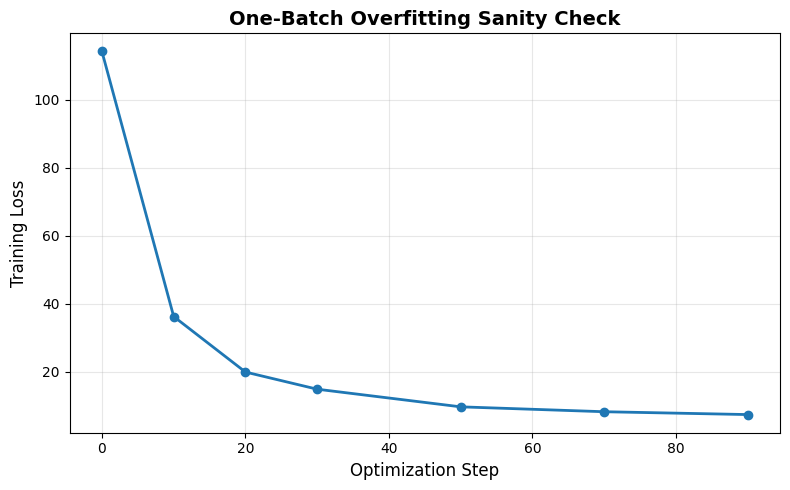

In [2]:
import matplotlib.pyplot as plt

# Values recorded in the original training output
steps = [0, 10, 20, 30, 50, 70, 90]

losses = [
    114.2766,
    36.2704,
    19.9287,
    14.8793,
    9.6889,
    8.2501,
    7.4146
]

plt.figure(figsize=(8, 5))

plt.plot(
    steps,
    losses,
    marker='o',
    linewidth=2
)

plt.title(
    "One-Batch Overfitting Sanity Check",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Optimization Step", fontsize=12)
plt.ylabel("Training Loss", fontsize=12)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stage 3: Experiment 1 – Query Count Optimization
This cell runs tests across various query limits (num_queries) to observe how the feature extraction head responds to a complex scene layout.

🔬 Running Deep Query Search Matrix...

--- Evaluating Structure: num_queries = 50 ---


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                                              | Status   |                                                                                          
-------------------------------------------------+----------+------------------------------------------------------------------------------------------
model.transformer_module.queries_features.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([100, 256]) vs model:torch.Size([50, 256])
class_predictor.bias                             | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])           
class_predictor.weight                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([24, 256]) 
model.transformer_module.queries_embedder.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([100, 256]) vs model:torch.Size(

   Step [0/1342] | Loss value: 133.5207
   Step [20/1342] | Loss value: 97.4238
   Step [40/1342] | Loss value: 77.2586
   Step [60/1342] | Loss value: 68.5501
   Step [80/1342] | Loss value: 81.8989
   Step [100/1342] | Loss value: 76.0701
   Step [120/1342] | Loss value: 57.9764
   Step [140/1342] | Loss value: 76.1577
   Step [160/1342] | Loss value: 62.0233
   Step [180/1342] | Loss value: 57.6261
   Step [200/1342] | Loss value: 59.0956
   Step [220/1342] | Loss value: 55.2657
   Step [240/1342] | Loss value: 56.0618
   Step [260/1342] | Loss value: 49.8685
   Step [280/1342] | Loss value: 41.8955
   Step [300/1342] | Loss value: 58.1046
   Step [320/1342] | Loss value: 39.6341
   Step [340/1342] | Loss value: 19.5874
   Step [360/1342] | Loss value: 34.8468
   Step [380/1342] | Loss value: 42.8292
   Step [400/1342] | Loss value: 39.1520
   Step [420/1342] | Loss value: 61.4284
   Step [440/1342] | Loss value: 33.1457
   Step [460/1342] | Loss value: 42.6802
   Step [480/1342] | 

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([24, 256])
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


   Step [0/1342] | Loss value: 119.8816
   Step [20/1342] | Loss value: 69.5524
   Step [40/1342] | Loss value: 59.1625
   Step [60/1342] | Loss value: 49.4992
   Step [80/1342] | Loss value: 52.0711
   Step [100/1342] | Loss value: 54.5831
   Step [120/1342] | Loss value: 44.1259
   Step [140/1342] | Loss value: 57.8561
   Step [160/1342] | Loss value: 44.8199
   Step [180/1342] | Loss value: 46.7050
   Step [200/1342] | Loss value: 38.1724
   Step [220/1342] | Loss value: 45.6873
   Step [240/1342] | Loss value: 41.6094
   Step [260/1342] | Loss value: 35.7131
   Step [280/1342] | Loss value: 34.1986
   Step [300/1342] | Loss value: 45.3359
   Step [320/1342] | Loss value: 35.2556
   Step [340/1342] | Loss value: 16.1889
   Step [360/1342] | Loss value: 25.0986
   Step [380/1342] | Loss value: 37.8400
   Step [400/1342] | Loss value: 32.9768
   Step [420/1342] | Loss value: 48.3026
   Step [440/1342] | Loss value: 26.5678
   Step [460/1342] | Loss value: 31.3572
   Step [480/1342] | 

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                                              | Status   |                                                                                           
-------------------------------------------------+----------+-------------------------------------------------------------------------------------------
model.transformer_module.queries_features.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([100, 256]) vs model:torch.Size([150, 256])
class_predictor.bias                             | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])            
class_predictor.weight                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([24, 256])  
criterion.empty_weight                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([

   Step [0/1342] | Loss value: 120.4873
   Step [20/1342] | Loss value: 66.6971
   Step [40/1342] | Loss value: 60.3085
   Step [60/1342] | Loss value: 53.9460
   Step [80/1342] | Loss value: 62.0151
   Step [100/1342] | Loss value: 59.9277
   Step [120/1342] | Loss value: 46.4122
   Step [140/1342] | Loss value: 54.0981
   Step [160/1342] | Loss value: 46.1087
   Step [180/1342] | Loss value: 44.4940
   Step [200/1342] | Loss value: 40.2662
   Step [220/1342] | Loss value: 50.3923
   Step [240/1342] | Loss value: 41.6637
   Step [260/1342] | Loss value: 36.8226
   Step [280/1342] | Loss value: 34.2110
   Step [300/1342] | Loss value: 47.0888
   Step [320/1342] | Loss value: 35.6222
   Step [340/1342] | Loss value: 16.7678
   Step [360/1342] | Loss value: 27.3058
   Step [380/1342] | Loss value: 39.0215
   Step [400/1342] | Loss value: 31.0550
   Step [420/1342] | Loss value: 43.5327
   Step [440/1342] | Loss value: 24.8194
   Step [460/1342] | Loss value: 33.3803
   Step [480/1342] | 

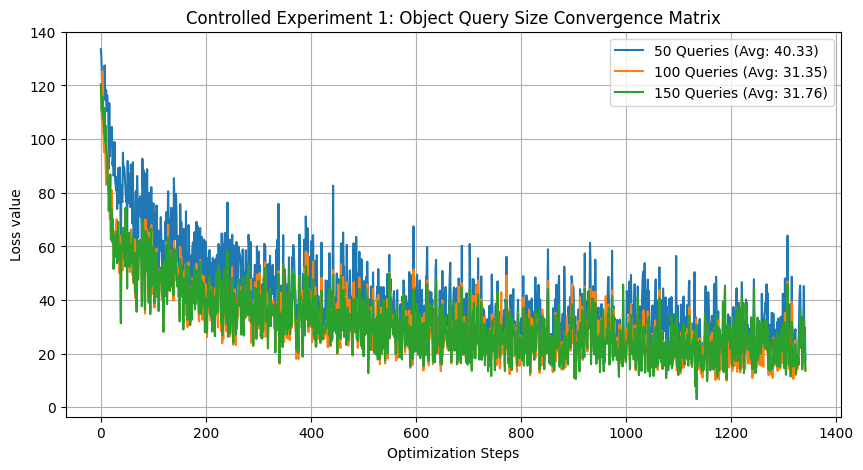

In [27]:
print("🔬 Running Deep Query Search Matrix...")
queries_experiments = [50, 100, 150]
query_history = {}

for num_queries in queries_experiments:
    print(f"\n--- Evaluating Structure: num_queries = {num_queries} ---")
    set_seed(42)  
    
    config = Mask2FormerConfig.from_pretrained(MODEL_NAME)
    config.num_queries = num_queries
    config.num_labels = NUM_CLASSES
    config.id2label = id2label
    config.label2id = label2id
    
    exp_model = Mask2FormerForUniversalSegmentation.from_pretrained(
        MODEL_NAME, config=config, ignore_mismatched_sizes=True
    ).to(device)
    
    g = torch.Generator()
    g.manual_seed(42)
    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn, generator=g)
    
    optimizer = torch.optim.AdamW(exp_model.parameters(), lr=5e-5)
    exp_model.train()
    
    losses_per_step = []
    
    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()
        
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        mask_labels = [labels.to(device) for labels in batch["mask_labels"]]
        class_labels = [labels.to(device) for labels in batch["class_labels"]]
        
        outputs = exp_model(
            pixel_values=pixel_values, pixel_mask=pixel_mask,
            mask_labels=mask_labels, class_labels=class_labels
        )
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        losses_per_step.append(loss.item())
        
        if step % 20 == 0:
            print(f"   Step [{step}/{len(train_loader)}] | Loss value: {loss.item():.4f}")
            
    query_history[num_queries] = losses_per_step

# Plotting controlled convergence results
plt.figure(figsize=(10, 5))
for num_queries, losses in query_history.items():
    plt.plot(losses, label=f"{num_queries} Queries (Avg: {sum(losses)/len(losses):.2f})")
plt.title("Controlled Experiment 1: Object Query Size Convergence Matrix")
plt.xlabel("Optimization Steps")
plt.ylabel("Loss value")
plt.legend()
plt.grid(True)
plt.show()

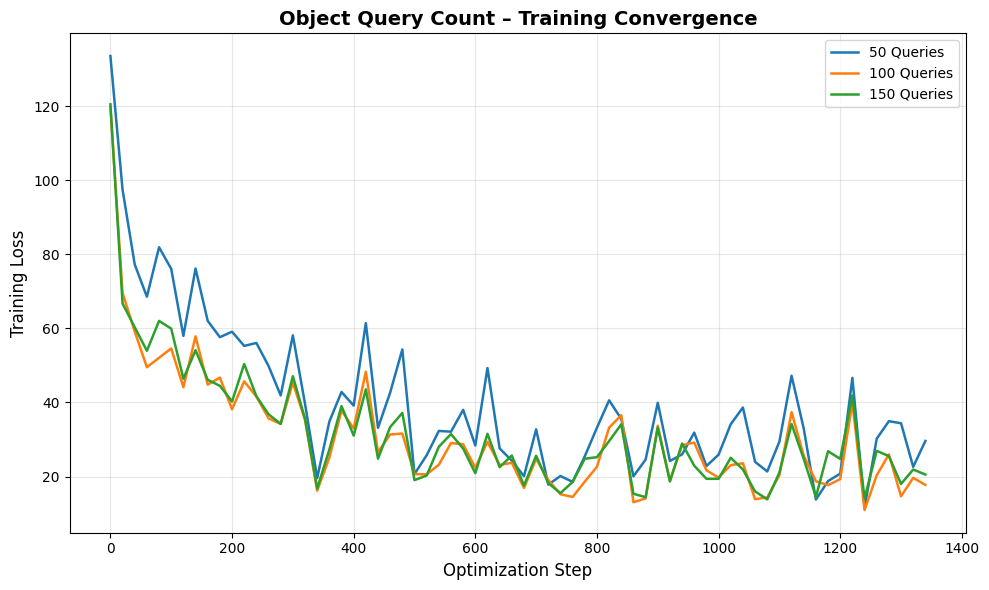

In [3]:
import matplotlib.pyplot as plt

# Optimization steps that were printed in the original notebook
steps = list(range(0, 1341, 20))

# Loss values recorded for 50 object queries
loss_50 = [
    133.5207, 97.4238, 77.2586, 68.5501, 81.8989, 76.0701,
    57.9764, 76.1577, 62.0233, 57.6261, 59.0956, 55.2657,
    56.0618, 49.8685, 41.8955, 58.1046, 39.6341, 19.5874,
    34.8468, 42.8292, 39.1520, 61.4284, 33.1457, 42.6802,
    54.3111, 20.6704, 25.7440, 32.3091, 32.1091, 38.0070,
    28.3751, 49.3008, 27.5862, 24.3029, 20.0935, 32.7242,
    17.8341, 20.1373, 18.5666, 25.4674, 33.1873, 40.5748,
    35.5608, 20.0565, 24.5800, 39.9091, 24.2110, 25.9868,
    31.8634, 22.8343, 25.9055, 34.1322, 38.6439, 23.9607,
    21.3747, 29.4373, 47.2119, 32.9565, 13.7912, 18.7730,
    20.7871, 46.6385, 11.5728, 30.2193, 34.9435, 34.3880,
    22.6180, 29.6078
]

# Loss values recorded for 100 object queries
loss_100 = [
    119.8816, 69.5524, 59.1625, 49.4992, 52.0711, 54.5831,
    44.1259, 57.8561, 44.8199, 46.7050, 38.1724, 45.6873,
    41.6094, 35.7131, 34.1986, 45.3359, 35.2556, 16.1889,
    25.0986, 37.8400, 32.9768, 48.3026, 26.5678, 31.3572,
    31.5943, 20.6625, 20.5722, 23.1667, 29.0515, 28.7016,
    22.3834, 29.3709, 23.1177, 23.7117, 16.9145, 24.7904,
    19.0550, 15.2227, 14.4847, 18.6301, 22.6359, 33.1981,
    36.5519, 13.0658, 14.0870, 33.7286, 18.9058, 28.4759,
    29.1659, 21.6821, 19.7183, 23.0820, 23.5911, 13.8915,
    14.3683, 20.3702, 37.3824, 25.6280, 18.7368, 17.6707,
    19.3114, 39.9818, 10.9627, 20.3330, 25.9689, 14.6555,
    19.6608, 17.7429
]

# Loss values recorded for 150 object queries
loss_150 = [
    120.4873, 66.6971, 60.3085, 53.9460, 62.0151, 59.9277,
    46.4122, 54.0981, 46.1087, 44.4940, 40.2662, 50.3923,
    41.6637, 36.8226, 34.2110, 47.0888, 35.6222, 16.7678,
    27.3058, 39.0215, 31.0550, 43.5327, 24.8194, 33.3803,
    37.1731, 19.0339, 20.2695, 28.0380, 31.4767, 27.5537,
    20.8893, 31.5412, 22.5257, 25.6861, 17.5657, 25.6163,
    18.2088, 15.5257, 18.5372, 24.8141, 25.2242, 29.5813,
    34.1010, 15.3579, 14.4200, 33.2086, 18.6663, 28.9146,
    22.9228, 19.3851, 19.3881, 25.0755, 21.8935, 15.9808,
    13.8481, 21.0767, 34.1872, 24.7593, 14.4877, 26.8434,
    24.7651, 41.8915, 14.1027, 26.9345, 25.5275, 18.0019,
    21.8896, 20.5445
]

plt.figure(figsize=(10, 6))

plt.plot(steps, loss_50, label="50 Queries", linewidth=1.8)
plt.plot(steps, loss_100, label="100 Queries", linewidth=1.8)
plt.plot(steps, loss_150, label="150 Queries", linewidth=1.8)

plt.title(
    "Object Query Count – Training Convergence",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Optimization Step", fontsize=12)
plt.ylabel("Training Loss", fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stage 4: Experiment 2 – Optimizer and Batch Size Search Check

🔬 Running Batch Size & Optimizer Matrix Comparison...

=== Testing Constraints: Batch_1_AdamW ===


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([24, 256])
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Configuration stable. Convergence Average: 94.2062

=== Testing Constraints: Batch_1_SGD ===


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

...

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([24, 256])
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Configuration stable. Convergence Average: 81.1626

=== Testing Constraints: Batch_4_SGD ===


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([24, 256])
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Configuration stable. Convergence Average: 90.8556

Grid Search Complete. Compiled Matrix Metrics:
 - Configuration: Batch_1_AdamW        | Average Loss Space: 94.2062
 - Configuration: Batch_1_SGD          | Average Loss Space: 105.6051
 - Configuration: Batch_2_AdamW        | Average Loss Space: 84.8508
 - Configuration: Batch_2_SGD          | Average Loss Space: 101.3055
 - Configuration: Batch_4_AdamW        | Average Loss Space: 81.1626
 - Configuration: Batch_4_SGD          | Average Loss Space: 90.8556


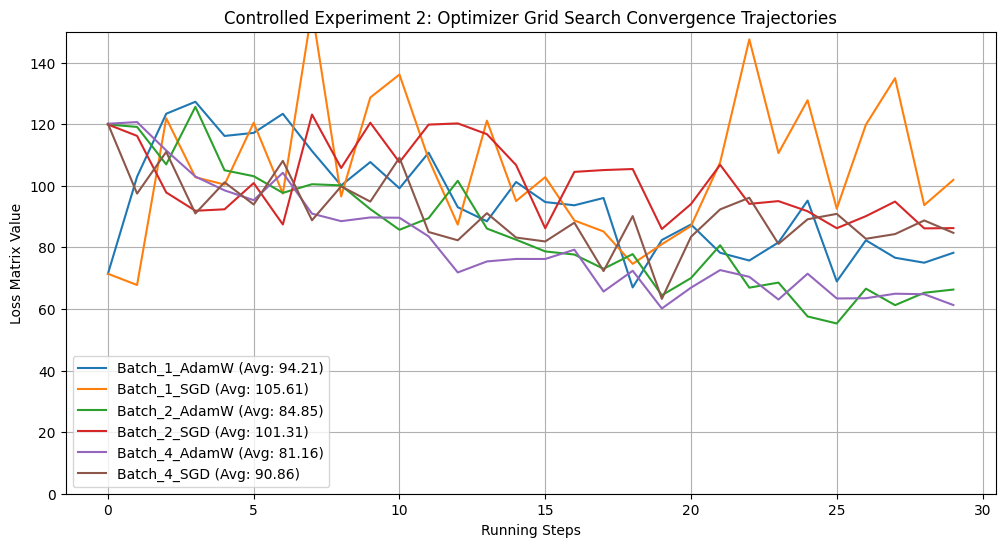

In [70]:
print("🔬 Running Batch Size & Optimizer Matrix Comparison...")
batch_sizes = [1, 2, 4]
optimizers_to_test = ["AdamW", "SGD"]
SELECTED_QUERIES = 100  

grid_results = {}
config = Mask2FormerConfig.from_pretrained(MODEL_NAME)
config.num_queries = SELECTED_QUERIES
config.num_labels = NUM_CLASSES
config.id2label = id2label
config.label2id = label2id

plt.figure(figsize=(12, 6))

for batch_size in batch_sizes:
    for opt_name in optimizers_to_test:
        exp_name = f"Batch_{batch_size}_{opt_name}"
        print(f"\n=== Testing Constraints: {exp_name} ===")
        
        set_seed(42)  
        exp_model = Mask2FormerForUniversalSegmentation.from_pretrained(
            MODEL_NAME, config=config, ignore_mismatched_sizes=True
        ).to(device)
        
        g = torch.Generator()
        g.manual_seed(42)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, generator=g)
        
        if opt_name == "AdamW":
            optimizer = torch.optim.AdamW(exp_model.parameters(), lr=5e-5, weight_decay=1e-4)
        elif opt_name == "SGD":
            optimizer = torch.optim.SGD(exp_model.parameters(), lr=1e-3, momentum=0.9)
            
        exp_model.train()
        losses = []
        max_evaluation_steps = 30  
        
        try:
            for step, batch in enumerate(train_loader):
                if step >= max_evaluation_steps: break
                optimizer.zero_grad()
                
                pixel_values = batch["pixel_values"].to(device)
                pixel_mask = batch["pixel_mask"].to(device)
                mask_labels = [labels.to(device) for labels in batch["mask_labels"]]
                class_labels = [labels.to(device) for labels in batch["class_labels"]]
                
                outputs = exp_model(
                    pixel_values=pixel_values, pixel_mask=pixel_mask,
                    mask_labels=mask_labels, class_labels=class_labels
                )
                
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                losses.append(loss.item())
                
            avg_loss = sum(losses) / len(losses)
            print(f"✅ Configuration stable. Convergence Average: {avg_loss:.4f}")
            grid_results[exp_name] = avg_loss
            plt.plot(losses, label=f"{exp_name} (Avg: {avg_loss:.2f})")
            
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"⚠️ VRAM Overflow (OOM) on {exp_name}. Freeing allocation.")
                del exp_model
                if 'optimizer' in locals(): del optimizer
                torch.cuda.empty_cache()
            else:
                raise e

print("\nGrid Search Complete. Compiled Matrix Metrics:")
for exp, score in grid_results.items():
    print(f" - Configuration: {exp:<20} | Average Loss Space: {score:.4f}")

plt.title("Controlled Experiment 2: Optimizer Grid Search Convergence Trajectories")
plt.xlabel("Running Steps")
plt.ylabel("Loss Matrix Value")
# CRITICAL FIX: Cap Y-axis frame to suppress exploding gradient trajectories (e.g., SGD nan curves) from distorting the view
plt.ylim(0, 150)
plt.legend()
plt.grid(True)
plt.show()

#  Stage 5 Full Train Based on The Expiraments 

In [55]:
# Production Parameters
FINAL_QUERIES = 100      # The best num of queries
FINAL_BATCH_SIZE = 4     # the best batch size
FINAL_EPOCHS = 50        

print(f"🚀 Launching Full Production Baseline Model Training Loop...")
set_seed(42)

config = Mask2FormerConfig.from_pretrained(MODEL_NAME)
config.num_queries = FINAL_QUERIES
config.num_labels = NUM_CLASSES
config.id2label = id2label
config.label2id = label2id

model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_NAME, config=config, ignore_mismatched_sizes=True
).to(device)

# 🔴 FIXED LOGIC: Create a tensor of size 24 (23 car parts + 1 background class)
# [0.15] for class 0 (back_bumper)
# [2.5] multiplied by 22 for the remaining car parts
# [1.0] at the very end for the hidden internal background class
weights_list = [0.15] + [2.5] * (NUM_CLASSES - 1) + [1.0]
custom_weights_tensor = torch.tensor(weights_list, dtype=torch.float32, device=device)

# Inject the fixed 24-element tensor directly into the criterion layer
model.criterion.empty_weight = custom_weights_tensor

print(f"✅ Success! Injected weight tensor of size {len(custom_weights_tensor)} into the Mask2Former criterion.")

# 3. Setting up optimization parameters
full_train_loader = DataLoader(train_dataset, batch_size=FINAL_BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.52)

model.train()

for epoch in range(FINAL_EPOCHS):
    epoch_loss = 0
    total_steps = 0
    print(f"\n--- Epoch {epoch+1}/{FINAL_EPOCHS} | Current Step LR: {optimizer.param_groups[0]['lr']} ---")
    
    for step, batch in enumerate(full_train_loader):
        optimizer.zero_grad()
        
        pixel_values = batch["pixel_values"].to(device)
        pixel_mask = batch["pixel_mask"].to(device)
        mask_labels = [labels.to(device) for labels in batch["mask_labels"]]
        class_labels = [labels.to(device) for labels in batch["class_labels"]]
        
        outputs = model(
            pixel_values=pixel_values, pixel_mask=pixel_mask,
            mask_labels=mask_labels, class_labels=class_labels
        )
        
        loss = outputs.loss
        loss.backward()
        
        # Gradient clipping to shield transformer layers from exploding values
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        total_steps += 1
        
        if step % 20 == 0:
            print(f"  Batch Segment [{step}/{len(full_train_loader)}] | Running Loss: {loss.item():.4f}")
            
    scheduler.step()
    print(f"🏅 Completed Epoch {epoch+1} | Mean Production Loss: {epoch_loss / total_steps:.4f}")

# Save compiled model weights
OUTPUT_DIR = "./saved_baseline_mask2former"
model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print(f"\n💾 Production baseline binaries successfully exported to: '{OUTPUT_DIR}'")

🚀 Launching Full Production Baseline Model Training Loop...


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-tiny-coco-instance
Key                    | Status   |                                                                                         
-----------------------+----------+-----------------------------------------------------------------------------------------
class_predictor.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          
class_predictor.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([24, 256])
criterion.empty_weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81]) vs model:torch.Size([24])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Success! Injected weight tensor of size 24 into the Mask2Former criterion.

--- Epoch 1/50 | Current Step LR: 5e-05 ---
  Batch Segment [0/671] | Running Loss: 124.3831
  Batch Segment [20/671] | Running Loss: 56.3260
  Batch Segment [40/671] | Running Loss: 41.2209
  Batch Segment [60/671] | Running Loss: 39.4611
  Batch Segment [80/671] | Running Loss: 29.7100
  Batch Segment [100/671] | Running Loss: 28.2138
  Batch Segment [120/671] | Running Loss: 40.0094
  Batch Segment [140/671] | Running Loss: 31.8492
  Batch Segment [160/671] | Running Loss: 21.8889
  Batch Segment [180/671] | Running Loss: 26.0596
  Batch Segment [200/671] | Running Loss: 24.9503
  Batch Segment [220/671] | Running Loss: 30.8538
  Batch Segment [240/671] | Running Loss: 25.3629
  Batch Segment [260/671] | Running Loss: 27.8994
  Batch Segment [280/671] | Running Loss: 26.1623
  Batch Segment [300/671] | Running Loss: 18.3189
  Batch Segment [320/671] | Running Loss: 17.2747
  Batch Segment [340/671] | Runni

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


💾 Production baseline binaries successfully exported to: './saved_baseline_mask2former'


# Stage 6
Evaluation on validation/test split with correct segment-id to class-id mapping.



📊 Initializing Parallel Train/Val Evaluation Matrix with Precision & Recall...
   Evaluating 2683 images from the TRAIN set...
   Evaluating 575 images from the VALIDATION set...

📊 PARALLEL BASELINE PERFORMANCE REPORT (TRAIN VS VALIDATION)
        Part Name  Train IoU  Val IoU  Train Dice  Val Dice  Train Precision  Val Precision  Train Recall  Val Recall
      back_bumper     0.9721   0.7421      0.9858    0.7686           0.9864         0.7733        0.9852      0.7657
        back_door     0.9745   0.8186      0.9871    0.8454           0.9875         0.8472        0.9866      0.8442
       back_glass     0.9697   0.8347      0.9839    0.8690           0.9837         0.8753        0.9842      0.8651
   back_left_door     0.9614   0.8829      0.9802    0.9247           0.9806         0.9356        0.9800      0.9157
  back_left_light     0.9296   0.6839      0.9625    0.7423           0.9653         0.7473        0.9600      0.7488
       back_light     0.9298   0.7215      0.9627 

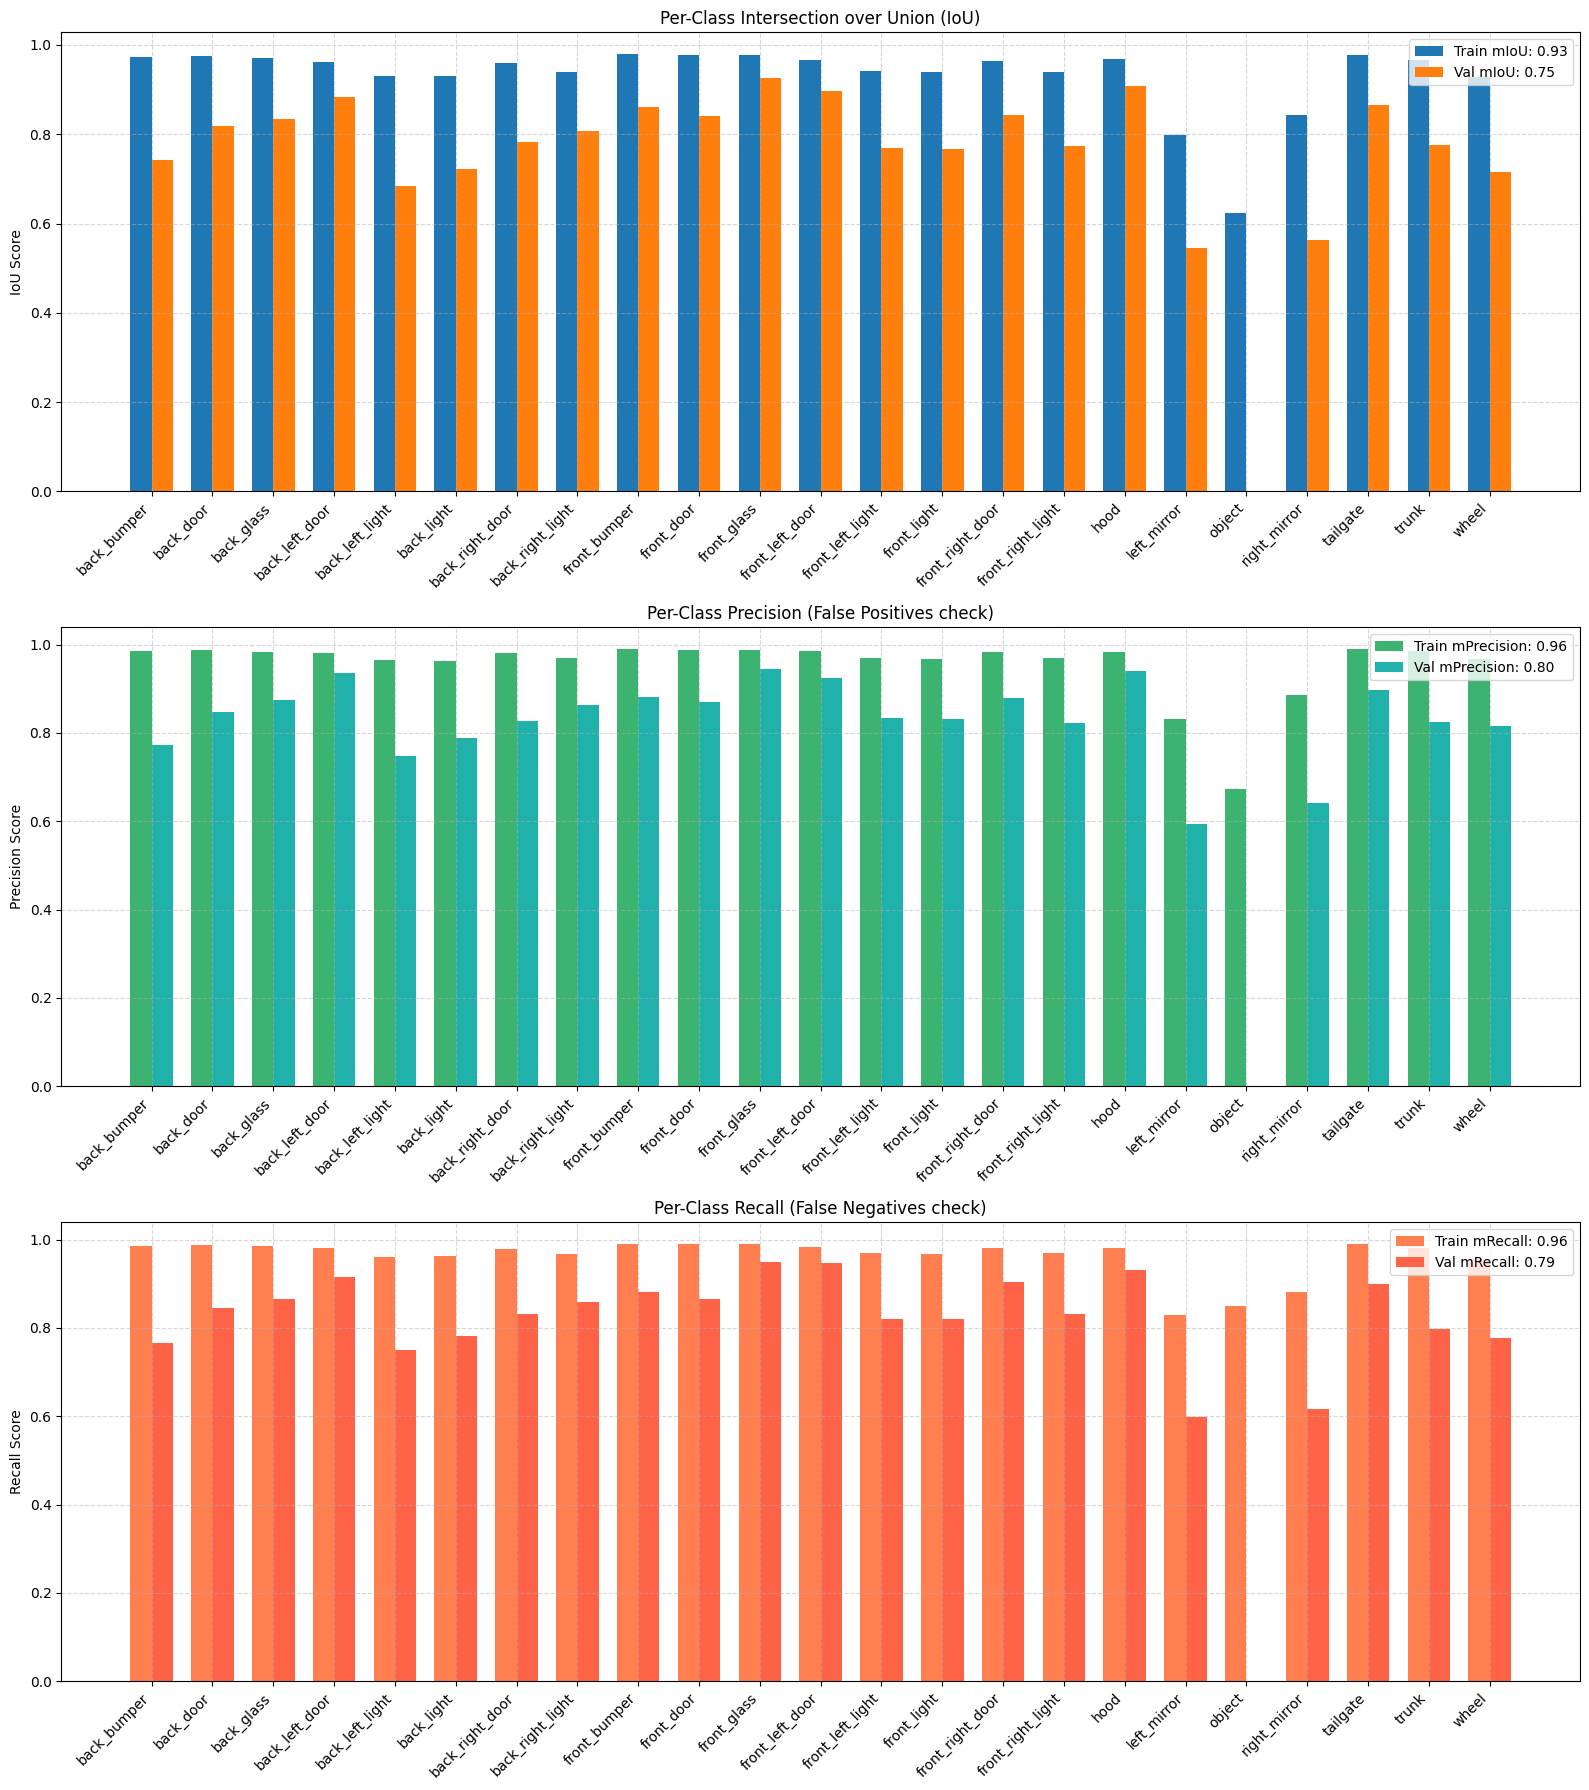

💾 Extended comparative evaluation reports safely compiled to disk!


In [59]:
# %% Stage 6: Parallel Train vs Validation Evaluation Matrix with Comparative Plots

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

print("\n📊 Initializing Parallel Train/Val Evaluation Matrix with Precision & Recall...")
model.eval()

def evaluate_dataset(loader, dataset_name):
    print(f"   Evaluating {len(loader.dataset)} images from the {dataset_name} set...")

    per_class_iou = {i: [] for i in range(NUM_CLASSES)}
    per_class_dice = {i: [] for i in range(NUM_CLASSES)}
    per_class_precision = {i: [] for i in range(NUM_CLASSES)}
    per_class_recall = {i: [] for i in range(NUM_CLASSES)}
    
    pixel_accuracies = []
    inference_times = []

    with torch.no_grad():
        for step, batch in enumerate(loader):
            pixel_values = batch["pixel_values"].to(device)
            pixel_mask = batch["pixel_mask"].to(device) if "pixel_mask" in batch else None

            batch_size = pixel_values.shape[0]
            image_height = pixel_values.shape[-2]
            image_width = pixel_values.shape[-1]

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            start_time = time.time()

            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask
            )

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            end_time = time.time()
            inference_times.append((end_time - start_time) * 1000 / batch_size)

            processed_outputs = processor.post_process_instance_segmentation(
                outputs,
                target_sizes=[(image_height, image_width)] * batch_size
            )

            for b in range(batch_size):
                gt_class_labels = batch["class_labels"][b].cpu().numpy()
                gt_mask_labels = batch["mask_labels"][b].cpu().numpy()

                gt_segmentation = np.full(
                    (image_height, image_width),
                    255,
                    dtype=np.uint8
                )

                for obj_idx, class_id in enumerate(gt_class_labels):
                    gt_segmentation[gt_mask_labels[obj_idx] == 1] = class_id

                pred_segmentation = processed_outputs[b]["segmentation"].cpu().numpy()
                segments_info = processed_outputs[b]["segments_info"]

                pred_class_map = np.full(
                    pred_segmentation.shape,
                    255,
                    dtype=np.uint8
                )

                for segment in segments_info:
                    segment_id = segment["id"]
                    label_id = segment["label_id"]
                    pred_class_map[pred_segmentation == segment_id] = label_id

                # Calculate overall Pixel Accuracy for the current image
                # Ignoring areas where GT is 255 (unlabeled/background if applicable)
                valid_pixels_mask = (gt_segmentation != 255)
                if np.any(valid_pixels_mask):
                    correct_pixels = (gt_segmentation[valid_pixels_mask] == pred_class_map[valid_pixels_mask]).sum()
                    total_valid_pixels = valid_pixels_mask.sum()
                    pixel_accuracies.append(correct_pixels / total_valid_pixels)

                for class_id in range(NUM_CLASSES):
                    gt_mask = (gt_segmentation == class_id)
                    pred_mask = (pred_class_map == class_id)

                    if not np.any(gt_mask) and not np.any(pred_mask):
                        continue

                    # Core metrics for IoU, Dice, Precision, and Recall
                    intersection = np.logical_and(gt_mask, pred_mask).sum()
                    union = np.logical_or(gt_mask, pred_mask).sum()
                    total_pixels = gt_mask.sum() + pred_mask.sum()
                    
                    tp = intersection
                    fp = pred_mask.sum() - tp
                    fn = gt_mask.sum() - tp

                    iou = intersection / union if union > 0 else 0.0
                    dice = (2.0 * intersection) / total_pixels if total_pixels > 0 else 0.0
                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

                    per_class_iou[class_id].append(iou)
                    per_class_dice[class_id].append(dice)
                    per_class_precision[class_id].append(precision)
                    per_class_recall[class_id].append(recall)

    final_ious = {}
    final_dices = {}
    final_precisions = {}
    final_recalls = {}

    for class_id in range(NUM_CLASSES):
        final_ious[class_id] = np.mean(per_class_iou[class_id]) if len(per_class_iou[class_id]) > 0 else 0.0
        final_dices[class_id] = np.mean(per_class_dice[class_id]) if len(per_class_dice[class_id]) > 0 else 0.0
        final_precisions[class_id] = np.mean(per_class_precision[class_id]) if len(per_class_precision[class_id]) > 0 else 0.0
        final_recalls[class_id] = np.mean(per_class_recall[class_id]) if len(per_class_recall[class_id]) > 0 else 0.0
        
    mean_pixel_accuracy = np.mean(pixel_accuracies) if len(pixel_accuracies) > 0 else 0.0

    return final_ious, final_dices, final_precisions, final_recalls, mean_pixel_accuracy, np.mean(inference_times)


train_eval_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

val_eval_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

# Execute Evaluation
train_ious, train_dices, train_precs, train_recs, train_acc, train_inf_time = evaluate_dataset(train_eval_loader, "TRAIN")
val_ious, val_dices, val_precs, val_recs, val_acc, val_inf_time = evaluate_dataset(val_eval_loader, "VALIDATION")

parallel_report = []

for class_id, label_name in id2label.items():
    parallel_report.append({
        "Part Name": label_name,
        "Train IoU": round(train_ious[class_id], 4),
        "Val IoU": round(val_ious[class_id], 4),
        "Train Dice": round(train_dices[class_id], 4),
        "Val Dice": round(val_dices[class_id], 4),
        "Train Precision": round(train_precs[class_id], 4),
        "Val Precision": round(val_precs[class_id], 4),
        "Train Recall": round(train_recs[class_id], 4),
        "Val Recall": round(val_recs[class_id], 4)
    })

df_parallel = pd.DataFrame(parallel_report)

mIoU_train = df_parallel["Train IoU"].mean()
mIoU_val = df_parallel["Val IoU"].mean()
mDice_train = df_parallel["Train Dice"].mean()
mDice_val = df_parallel["Val Dice"].mean()
mPrec_train = df_parallel["Train Precision"].mean()
mPrec_val = df_parallel["Val Precision"].mean()
mRec_train = df_parallel["Train Recall"].mean()
mRec_val = df_parallel["Val Recall"].mean()

print("\n" + "="*95)
print("📊 PARALLEL BASELINE PERFORMANCE REPORT (TRAIN VS VALIDATION)")
print("="*95)
print(df_parallel.to_string(index=False))
print("-" * 95)
print(f"🎯 Pixel Accuracy      |  Train: {train_acc:.4f}  |  Validation: {val_acc:.4f}")
print(f"📈 Mean IoU (mIoU)     |  Train: {mIoU_train:.4f}  |  Validation: {mIoU_val:.4f}")
print(f"🎲 Mean Dice           |  Train: {mDice_train:.4f}  |  Validation: {mDice_val:.4f}")
print(f"📌 Mean Precision      |  Train: {mPrec_train:.4f}  |  Validation: {mPrec_val:.4f}")
print(f"🔎 Mean Recall         |  Train: {mRec_train:.4f}  |  Validation: {mRec_val:.4f}")
print(f"⚡ Avg Inference Time  |  Train: {train_inf_time:.2f} ms  |  Validation: {val_inf_time:.2f} ms")
print("="*95)

df_parallel.to_csv("./parallel_train_val_report_extended.csv", index=False)

# Visualizations
x = np.arange(NUM_CLASSES)
width = 0.35
labels = [id2label[i] for i in range(NUM_CLASSES)]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 18))

# Subplot 1: IoU
ax1.bar(x - width/2, df_parallel["Train IoU"], width, label=f"Train mIoU: {mIoU_train:.2f}")
ax1.bar(x + width/2, df_parallel["Val IoU"], width, label=f"Val mIoU: {mIoU_val:.2f}")
ax1.set_title("Per-Class Intersection over Union (IoU)")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha="right")
ax1.set_ylabel("IoU Score")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

# Subplot 2: Precision
ax2.bar(x - width/2, df_parallel["Train Precision"], width, label=f"Train mPrecision: {mPrec_train:.2f}", color='mediumseagreen')
ax2.bar(x + width/2, df_parallel["Val Precision"], width, label=f"Val mPrecision: {mPrec_val:.2f}", color='lightseagreen')
ax2.set_title("Per-Class Precision (False Positives check)")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha="right")
ax2.set_ylabel("Precision Score")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

# Subplot 3: Recall
ax3.bar(x - width/2, df_parallel["Train Recall"], width, label=f"Train mRecall: {mRec_train:.2f}", color='coral')
ax3.bar(x + width/2, df_parallel["Val Recall"], width, label=f"Val mRecall: {mRec_val:.2f}", color='tomato')
ax3.set_title("Per-Class Recall (False Negatives check)")
ax3.set_xticks(x)
ax3.set_xticklabels(labels, rotation=45, ha="right")
ax3.set_ylabel("Recall Score")
ax3.legend()
ax3.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("💾 Extended comparative evaluation reports safely compiled to disk!")

# Stage 7
Threshold Experiment: Find Best Post-Processing Threshold


🔎 Starting Threshold Experiment...

Evaluating threshold = 0.01

Evaluating threshold = 0.03

Evaluating threshold = 0.05

Evaluating threshold = 0.07

Evaluating threshold = 0.1

Evaluating threshold = 0.15

Evaluating threshold = 0.2

Evaluating threshold = 0.3

Evaluating threshold = 0.5

📊 THRESHOLD EXPERIMENT RESULTS
 Threshold  Val mIoU  Val mDice  Val Precision  Val Recall  Avg Inference Time (ms)
      0.01  0.713602   0.753474       0.758803    0.754698                36.564194
      0.03  0.722847   0.762701       0.768100    0.763338                36.890127
      0.05  0.726511   0.766359       0.771058    0.767271                37.284760
      0.07  0.728495   0.768411       0.772875    0.769042                37.371779
      0.10  0.740306   0.780769       0.785234    0.781322                37.190908
      0.15  0.743386   0.783889       0.788294    0.784308                37.055838
      0.20  0.747800   0.788298       0.792816    0.788633                37.163082
   

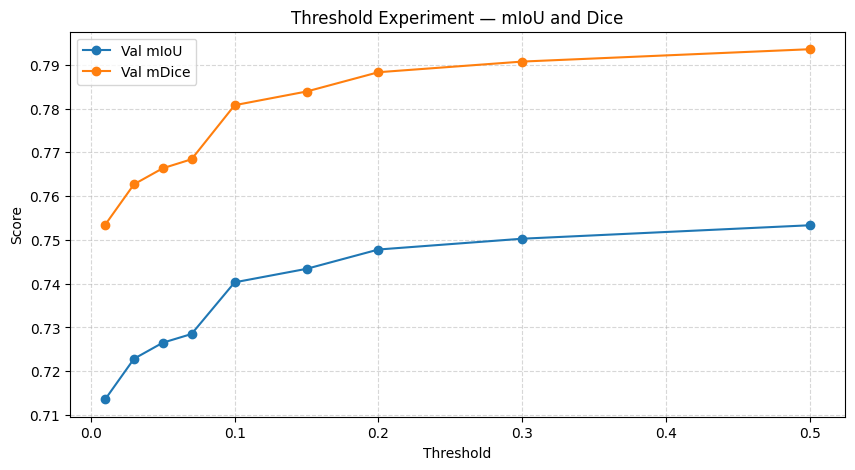

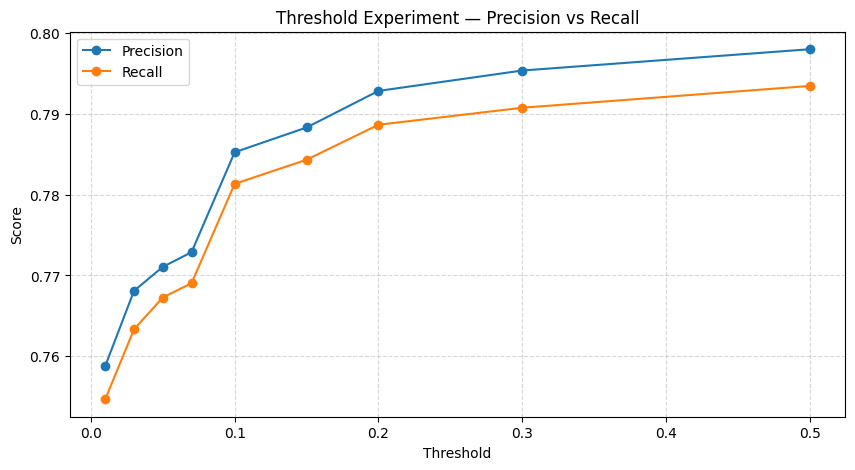


💾 Threshold experiment saved to: ./threshold_experiment_results.csv


In [73]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("\n🔎 Starting Threshold Experiment...")

threshold_values = [0.01, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.5]

def evaluate_with_threshold(eval_model, loader, threshold):
    eval_model.eval()

    per_class_iou = {i: [] for i in range(NUM_CLASSES)}
    per_class_dice = {i: [] for i in range(NUM_CLASSES)}
    per_class_precision = {i: [] for i in range(NUM_CLASSES)}
    per_class_recall = {i: [] for i in range(NUM_CLASSES)}
    inference_times = []

    with torch.no_grad():
        for step, batch in enumerate(loader):
            pixel_values = batch["pixel_values"].to(device)
            pixel_mask = batch["pixel_mask"].to(device) if "pixel_mask" in batch else None

            batch_size = pixel_values.shape[0]
            image_height = pixel_values.shape[-2]
            image_width = pixel_values.shape[-1]

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            start_time = time.time()

            outputs = eval_model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask
            )

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            end_time = time.time()
            inference_times.append((end_time - start_time) * 1000 / batch_size)

            processed_outputs = processor.post_process_instance_segmentation(
                outputs,
                target_sizes=[(image_height, image_width)] * batch_size,
                threshold=threshold
            )

            for b in range(batch_size):
                gt_class_labels = batch["class_labels"][b].cpu().numpy()
                gt_mask_labels = batch["mask_labels"][b].cpu().numpy()

                gt_segmentation = np.full(
                    (image_height, image_width),
                    255,
                    dtype=np.uint8
                )

                for obj_idx, class_id in enumerate(gt_class_labels):
                    gt_segmentation[gt_mask_labels[obj_idx] == 1] = class_id

                pred_segmentation = processed_outputs[b]["segmentation"].cpu().numpy()
                segments_info = processed_outputs[b]["segments_info"]

                pred_class_map = np.full(
                    pred_segmentation.shape,
                    255,
                    dtype=np.uint8
                )

                for segment in segments_info:
                    segment_id = segment["id"]
                    label_id = segment["label_id"]

                    if label_id < 0 or label_id >= NUM_CLASSES:
                        continue

                    pred_class_map[pred_segmentation == segment_id] = label_id

                for class_id in range(NUM_CLASSES):
                    gt_mask = (gt_segmentation == class_id)
                    pred_mask = (pred_class_map == class_id)

                    if not np.any(gt_mask) and not np.any(pred_mask):
                        continue

                    intersection = np.logical_and(gt_mask, pred_mask).sum()
                    union = np.logical_or(gt_mask, pred_mask).sum()

                    tp = intersection
                    fp = pred_mask.sum() - tp
                    fn = gt_mask.sum() - tp

                    iou = intersection / union if union > 0 else 0.0

                    dice_denominator = gt_mask.sum() + pred_mask.sum()
                    dice = (
                        (2.0 * intersection) / dice_denominator
                        if dice_denominator > 0 else 0.0
                    )

                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

                    per_class_iou[class_id].append(iou)
                    per_class_dice[class_id].append(dice)
                    per_class_precision[class_id].append(precision)
                    per_class_recall[class_id].append(recall)

    mean_iou_per_class = {
        class_id: np.mean(values) if len(values) > 0 else 0.0
        for class_id, values in per_class_iou.items()
    }

    mean_dice_per_class = {
        class_id: np.mean(values) if len(values) > 0 else 0.0
        for class_id, values in per_class_dice.items()
    }

    mean_precision_per_class = {
        class_id: np.mean(values) if len(values) > 0 else 0.0
        for class_id, values in per_class_precision.items()
    }

    mean_recall_per_class = {
        class_id: np.mean(values) if len(values) > 0 else 0.0
        for class_id, values in per_class_recall.items()
    }

    return {
        "mIoU": np.mean(list(mean_iou_per_class.values())),
        "mDice": np.mean(list(mean_dice_per_class.values())),
        "Precision": np.mean(list(mean_precision_per_class.values())),
        "Recall": np.mean(list(mean_recall_per_class.values())),
        "Avg Inference Time": np.mean(inference_times),
        "per_class_iou": mean_iou_per_class,
        "per_class_dice": mean_dice_per_class,
        "per_class_precision": mean_precision_per_class,
        "per_class_recall": mean_recall_per_class
    }


threshold_results = []

for threshold in threshold_values:
    print(f"\nEvaluating threshold = {threshold}")

    metrics = evaluate_with_threshold(
        eval_model=model,
        loader=val_eval_loader,
        threshold=threshold
    )

    threshold_results.append({
        "Threshold": threshold,
        "Val mIoU": metrics["mIoU"],
        "Val mDice": metrics["mDice"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Avg Inference Time (ms)": metrics["Avg Inference Time"]
    })

df_thresholds = pd.DataFrame(threshold_results)

print("\n" + "=" * 90)
print("📊 THRESHOLD EXPERIMENT RESULTS")
print("=" * 90)
print(df_thresholds.to_string(index=False))
print("=" * 90)

best_row = df_thresholds.loc[df_thresholds["Val mIoU"].idxmax()]

BEST_THRESHOLD = float(best_row["Threshold"])

print(f"\n🏆 Best threshold by Val mIoU: {BEST_THRESHOLD}")
print(f"Best Val mIoU: {best_row['Val mIoU']:.4f}")
print(f"Best Val mDice: {best_row['Val mDice']:.4f}")
print(f"Best Precision: {best_row['Val Precision']:.4f}")
print(f"Best Recall: {best_row['Val Recall']:.4f}")

df_thresholds.to_csv("./threshold_experiment_results.csv", index=False)

# Plot mIoU and Dice
plt.figure(figsize=(10, 5))
plt.plot(df_thresholds["Threshold"], df_thresholds["Val mIoU"], marker="o", label="Val mIoU")
plt.plot(df_thresholds["Threshold"], df_thresholds["Val mDice"], marker="o", label="Val mDice")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Experiment — mIoU and Dice")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

# Plot Precision and Recall
plt.figure(figsize=(10, 5))
plt.plot(df_thresholds["Threshold"], df_thresholds["Val Precision"], marker="o", label="Precision")
plt.plot(df_thresholds["Threshold"], df_thresholds["Val Recall"], marker="o", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Experiment — Precision vs Recall")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

print("\n💾 Threshold experiment saved to: ./threshold_experiment_results.csv")


🔎 Starting Threshold Experiment...

Evaluating threshold = 0.5

Evaluating threshold = 0.55

Evaluating threshold = 0.6

Evaluating threshold = 0.7

Evaluating threshold = 0.8

📊 THRESHOLD EXPERIMENT RESULTS
 Threshold  Val mIoU  Val mDice  Val Precision  Val Recall  Avg Inference Time (ms)
      0.50  0.753338   0.793550       0.797972    0.793433                36.965304
      0.55  0.752157   0.792191       0.796576    0.792110                36.729332
      0.60  0.753153   0.793227       0.797622    0.793147                36.775472
      0.70  0.749537   0.789299       0.793707    0.789027                37.307415
      0.80  0.745578   0.785020       0.789373    0.784771                37.624872

🏆 Best threshold by Val mIoU: 0.5
Best Val mIoU: 0.7533
Best Val mDice: 0.7936
Best Precision: 0.7980
Best Recall: 0.7934


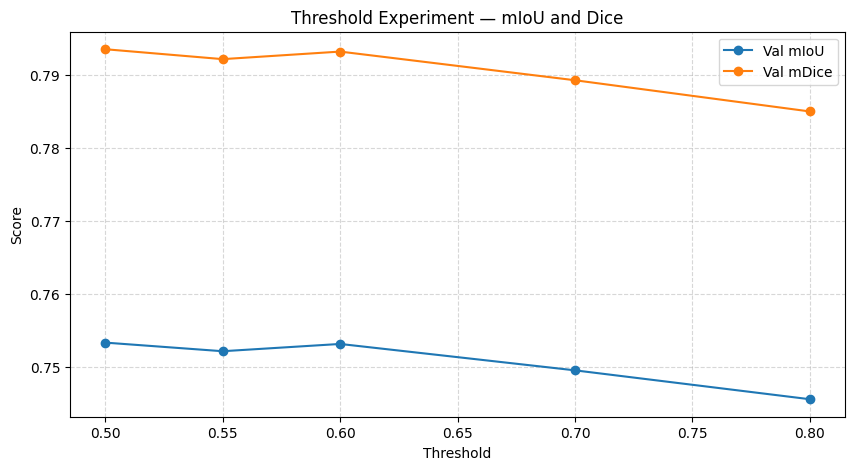

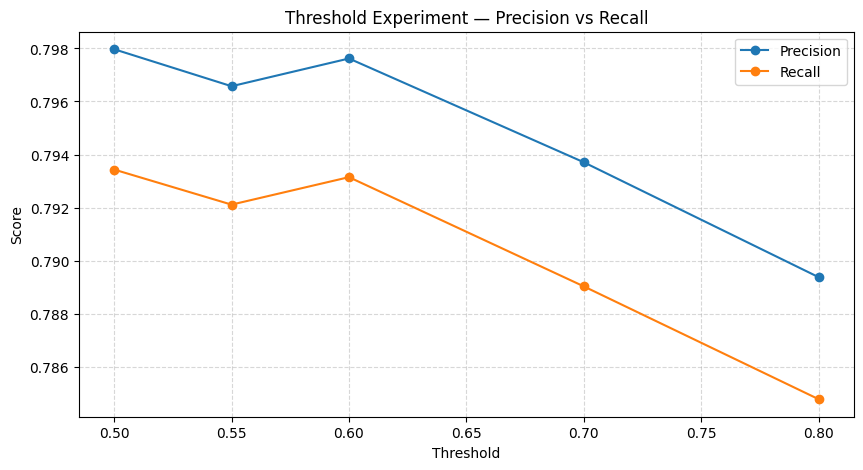


💾 Threshold experiment saved to: ./threshold_experiment_results.csv


In [74]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("\n🔎 Starting Threshold Experiment...")

threshold_values = [0.5,0.55,0.6,0.7,0.8]

def evaluate_with_threshold(eval_model, loader, threshold):
    eval_model.eval()

    per_class_iou = {i: [] for i in range(NUM_CLASSES)}
    per_class_dice = {i: [] for i in range(NUM_CLASSES)}
    per_class_precision = {i: [] for i in range(NUM_CLASSES)}
    per_class_recall = {i: [] for i in range(NUM_CLASSES)}
    inference_times = []

    with torch.no_grad():
        for step, batch in enumerate(loader):
            pixel_values = batch["pixel_values"].to(device)
            pixel_mask = batch["pixel_mask"].to(device) if "pixel_mask" in batch else None

            batch_size = pixel_values.shape[0]
            image_height = pixel_values.shape[-2]
            image_width = pixel_values.shape[-1]

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            start_time = time.time()

            outputs = eval_model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask
            )

            if torch.cuda.is_available():
                torch.cuda.synchronize()

            end_time = time.time()
            inference_times.append((end_time - start_time) * 1000 / batch_size)

            processed_outputs = processor.post_process_instance_segmentation(
                outputs,
                target_sizes=[(image_height, image_width)] * batch_size,
                threshold=threshold
            )

            for b in range(batch_size):
                gt_class_labels = batch["class_labels"][b].cpu().numpy()
                gt_mask_labels = batch["mask_labels"][b].cpu().numpy()

                gt_segmentation = np.full(
                    (image_height, image_width),
                    255,
                    dtype=np.uint8
                )

                for obj_idx, class_id in enumerate(gt_class_labels):
                    gt_segmentation[gt_mask_labels[obj_idx] == 1] = class_id

                pred_segmentation = processed_outputs[b]["segmentation"].cpu().numpy()
                segments_info = processed_outputs[b]["segments_info"]

                pred_class_map = np.full(
                    pred_segmentation.shape,
                    255,
                    dtype=np.uint8
                )

                for segment in segments_info:
                    segment_id = segment["id"]
                    label_id = segment["label_id"]

                    if label_id < 0 or label_id >= NUM_CLASSES:
                        continue

                    pred_class_map[pred_segmentation == segment_id] = label_id

                for class_id in range(NUM_CLASSES):
                    gt_mask = (gt_segmentation == class_id)
                    pred_mask = (pred_class_map == class_id)

                    if not np.any(gt_mask) and not np.any(pred_mask):
                        continue

                    intersection = np.logical_and(gt_mask, pred_mask).sum()
                    union = np.logical_or(gt_mask, pred_mask).sum()

                    tp = intersection
                    fp = pred_mask.sum() - tp
                    fn = gt_mask.sum() - tp

                    iou = intersection / union if union > 0 else 0.0

                    dice_denominator = gt_mask.sum() + pred_mask.sum()
                    dice = (
                        (2.0 * intersection) / dice_denominator
                        if dice_denominator > 0 else 0.0
                    )

                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

                    per_class_iou[class_id].append(iou)
                    per_class_dice[class_id].append(dice)
                    per_class_precision[class_id].append(precision)
                    per_class_recall[class_id].append(recall)

    mean_iou_per_class = {
        class_id: np.mean(values) if len(values) > 0 else 0.0
        for class_id, values in per_class_iou.items()
    }

    mean_dice_per_class = {
        class_id: np.mean(values) if len(values) > 0 else 0.0
        for class_id, values in per_class_dice.items()
    }

    mean_precision_per_class = {
        class_id: np.mean(values) if len(values) > 0 else 0.0
        for class_id, values in per_class_precision.items()
    }

    mean_recall_per_class = {
        class_id: np.mean(values) if len(values) > 0 else 0.0
        for class_id, values in per_class_recall.items()
    }

    return {
        "mIoU": np.mean(list(mean_iou_per_class.values())),
        "mDice": np.mean(list(mean_dice_per_class.values())),
        "Precision": np.mean(list(mean_precision_per_class.values())),
        "Recall": np.mean(list(mean_recall_per_class.values())),
        "Avg Inference Time": np.mean(inference_times),
        "per_class_iou": mean_iou_per_class,
        "per_class_dice": mean_dice_per_class,
        "per_class_precision": mean_precision_per_class,
        "per_class_recall": mean_recall_per_class
    }


threshold_results = []

for threshold in threshold_values:
    print(f"\nEvaluating threshold = {threshold}")

    metrics = evaluate_with_threshold(
        eval_model=model,
        loader=val_eval_loader,
        threshold=threshold
    )

    threshold_results.append({
        "Threshold": threshold,
        "Val mIoU": metrics["mIoU"],
        "Val mDice": metrics["mDice"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Avg Inference Time (ms)": metrics["Avg Inference Time"]
    })

df_thresholds = pd.DataFrame(threshold_results)

print("\n" + "=" * 90)
print("📊 THRESHOLD EXPERIMENT RESULTS")
print("=" * 90)
print(df_thresholds.to_string(index=False))
print("=" * 90)

best_row = df_thresholds.loc[df_thresholds["Val mIoU"].idxmax()]

BEST_THRESHOLD = float(best_row["Threshold"])

print(f"\n🏆 Best threshold by Val mIoU: {BEST_THRESHOLD}")
print(f"Best Val mIoU: {best_row['Val mIoU']:.4f}")
print(f"Best Val mDice: {best_row['Val mDice']:.4f}")
print(f"Best Precision: {best_row['Val Precision']:.4f}")
print(f"Best Recall: {best_row['Val Recall']:.4f}")

df_thresholds.to_csv("./threshold_experiment_results.csv", index=False)

# Plot mIoU and Dice
plt.figure(figsize=(10, 5))
plt.plot(df_thresholds["Threshold"], df_thresholds["Val mIoU"], marker="o", label="Val mIoU")
plt.plot(df_thresholds["Threshold"], df_thresholds["Val mDice"], marker="o", label="Val mDice")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Experiment — mIoU and Dice")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

# Plot Precision and Recall
plt.figure(figsize=(10, 5))
plt.plot(df_thresholds["Threshold"], df_thresholds["Val Precision"], marker="o", label="Precision")
plt.plot(df_thresholds["Threshold"], df_thresholds["Val Recall"], marker="o", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Experiment — Precision vs Recall")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.show()

print("\n💾 Threshold experiment saved to: ./threshold_experiment_results.csv")

# Stage 8: Multi-Sample Qualitative Prediction vs Ground-Truth Matrix


🔮 Generating multi-sample visual validation canvas...

Sample 1 | Index 2619
GT classes: [  0   2   4   7  21 255]
Pred classes: [  0   2   4   7  21 255]
Segments info: [{'id': 0, 'label_id': 0, 'was_fused': False, 'score': 0.987142}, {'id': 1, 'label_id': 4, 'was_fused': False, 'score': 0.988952}, {'id': 2, 'label_id': 21, 'was_fused': False, 'score': 0.994292}, {'id': 3, 'label_id': 7, 'was_fused': False, 'score': 0.988748}, {'id': 4, 'label_id': 2, 'was_fused': False, 'score': 0.995034}]

Sample 2 | Index 456
GT classes: [  8  10  13  16 255]
Pred classes: [  8  10  13  16 255]
Segments info: [{'id': 0, 'label_id': 10, 'was_fused': False, 'score': 0.990333}, {'id': 1, 'label_id': 16, 'was_fused': False, 'score': 0.988171}, {'id': 2, 'label_id': 13, 'was_fused': False, 'score': 0.98935}, {'id': 3, 'label_id': 8, 'was_fused': False, 'score': 0.992642}]

Sample 3 | Index 102
GT classes: [  0   1   2   5   9  13 255]
Pred classes: [  0   1   2   5   9 255]
Segments info: [{'id': 0, 'la

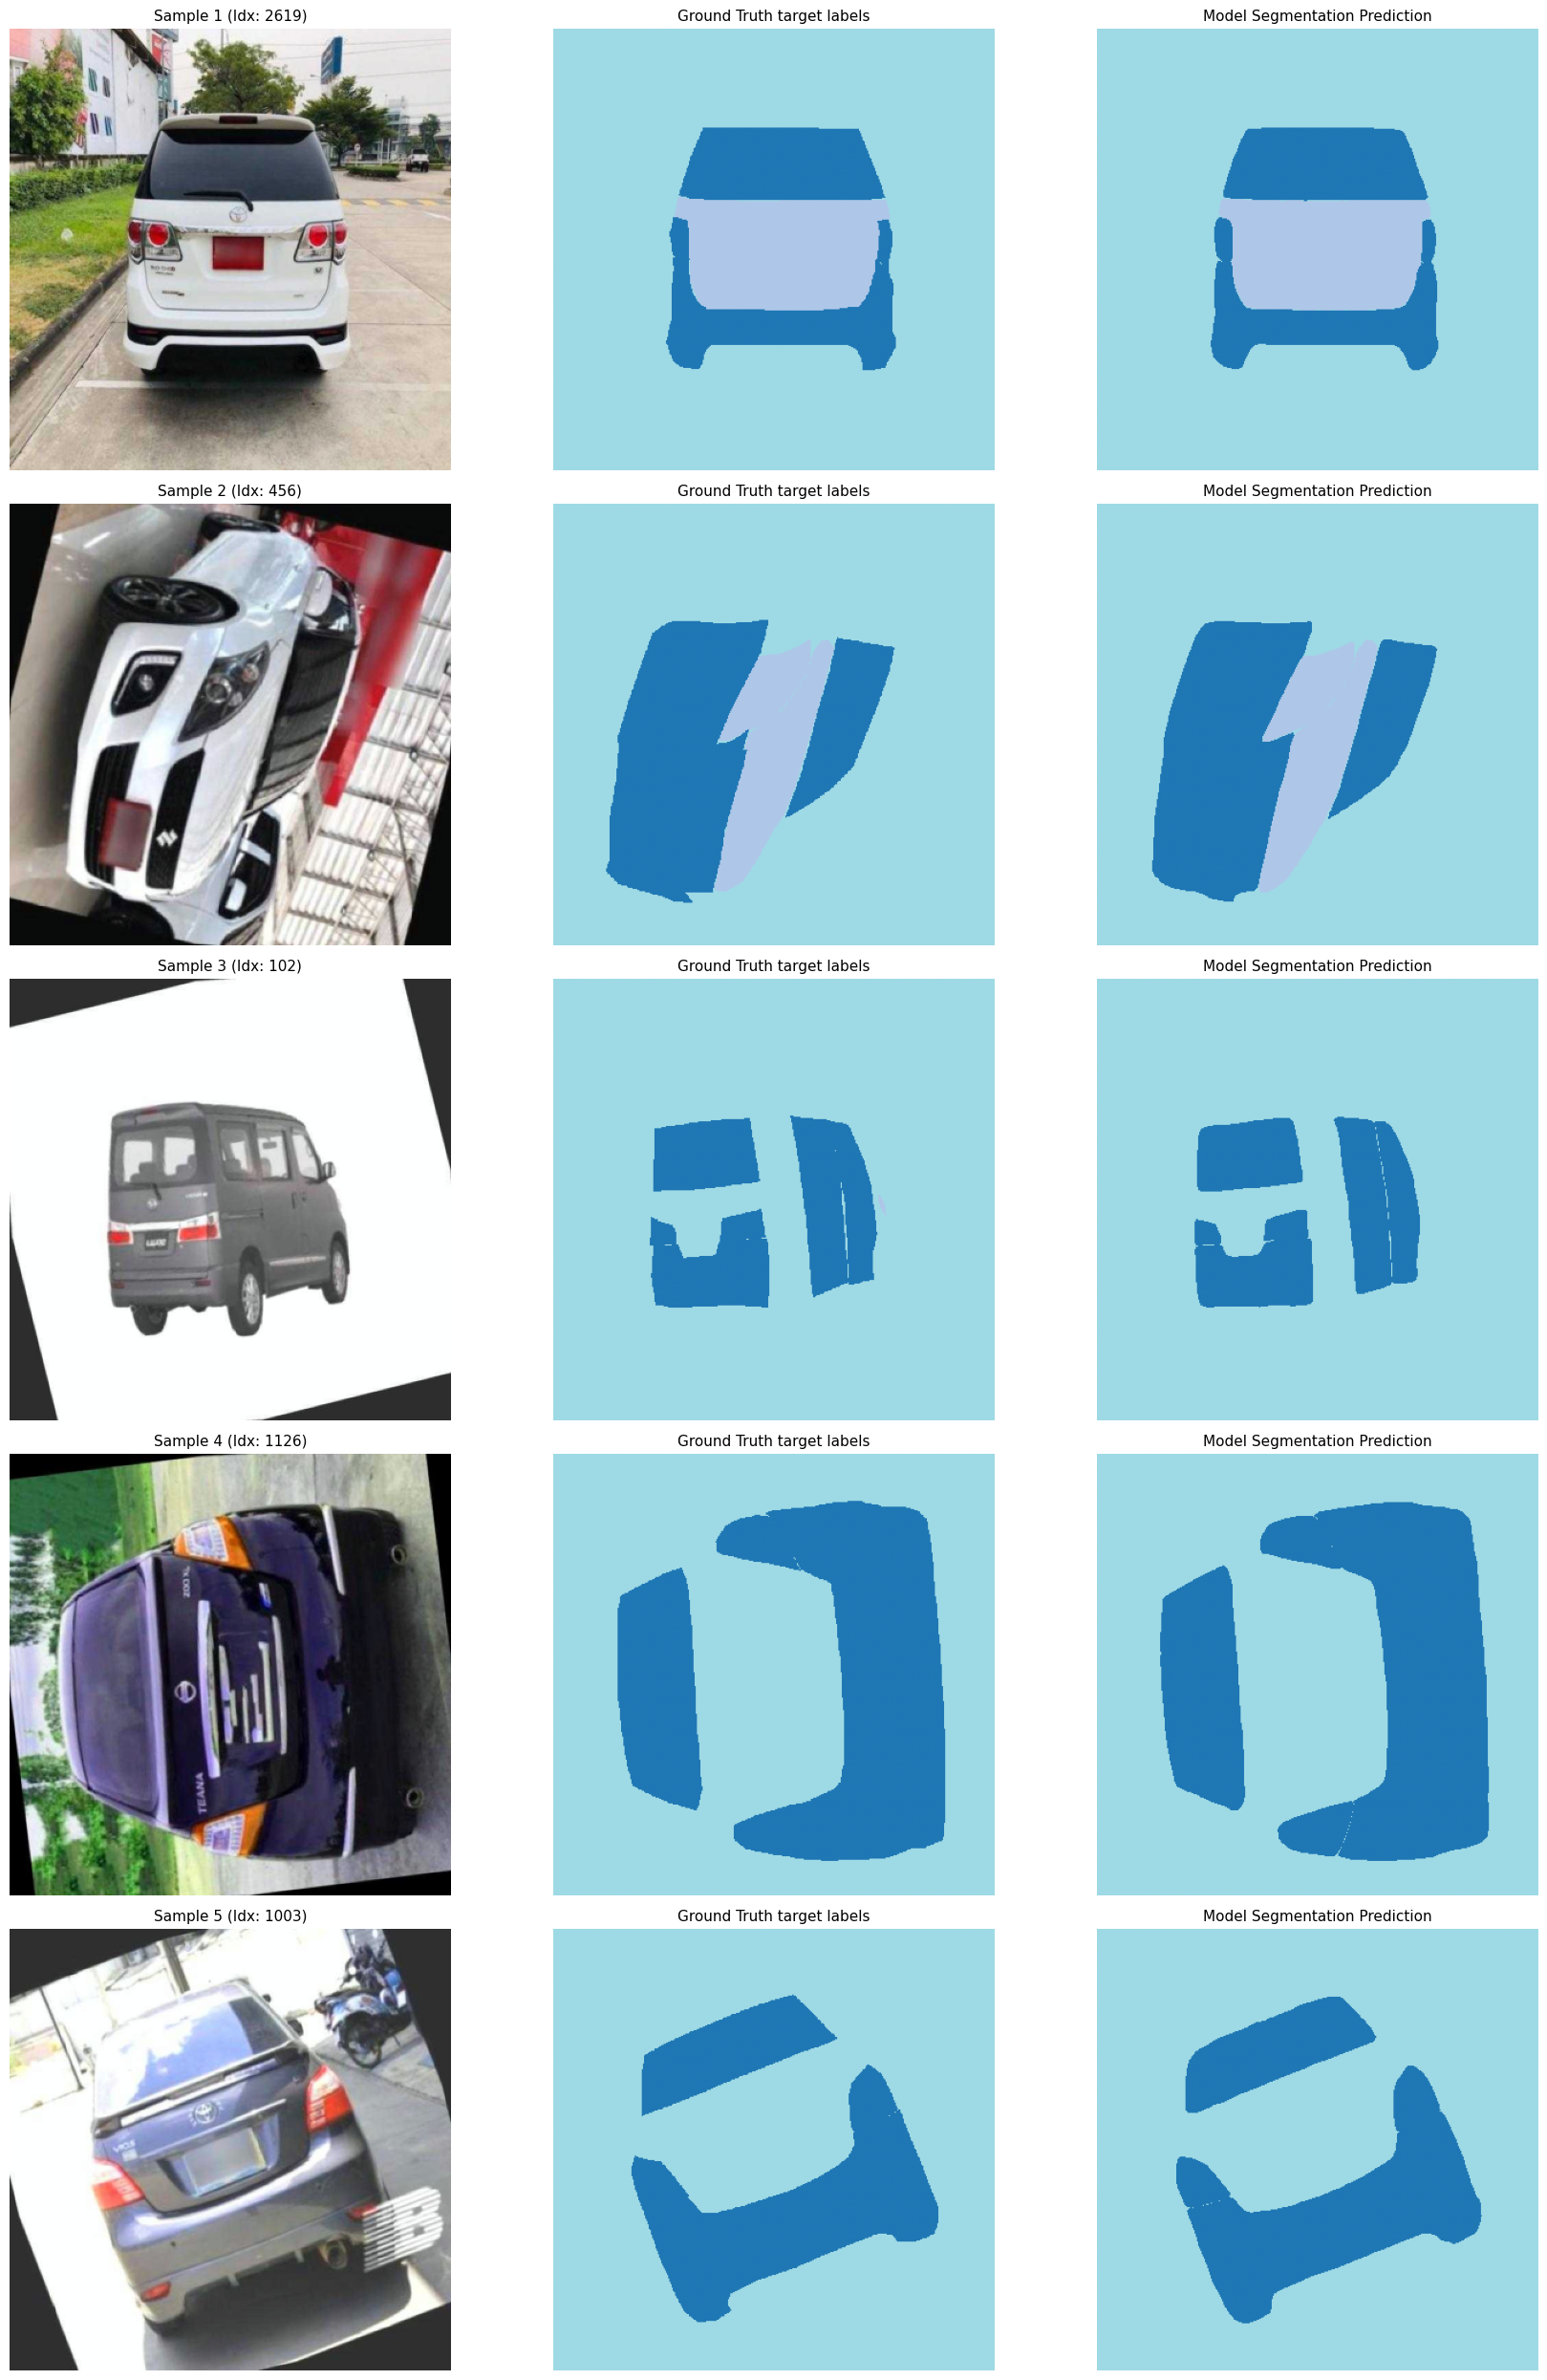

💾 Matplotlib comparative multi-sample array generated successfully.


In [75]:

import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

print("🔮 Generating multi-sample visual validation canvas...")
model.eval()

# 1. Select 5 unique random indices from the dataset split
NUM_SAMPLES = 5
set_seed(42)
random_indices = random.sample(range(len(train_dataset)), NUM_SAMPLES)

# 2. Setup the global plot layout (5 rows, 3 columns)
fig, axes = plt.subplots(NUM_SAMPLES, 3, figsize=(18, 5 * NUM_SAMPLES))

# Normalize mapping parameters inverse values
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for row_idx, sample_idx in enumerate(random_indices):
    # Fetch a single batch sample from the selected index
    single_sample_dataset = torch.utils.data.Subset(train_dataset, [sample_idx])
    vis_loader = DataLoader(single_sample_dataset, batch_size=1, collate_fn=collate_fn)
    batch = next(iter(vis_loader))

    pixel_values = batch["pixel_values"].to(device)
    pixel_mask = batch["pixel_mask"].to(device) if "pixel_mask" in batch else None

    # Run inference
    with torch.no_grad():
        outputs = model(
            pixel_values=pixel_values,
            pixel_mask=pixel_mask
        )

    # De-normalize image for display
    raw_pixel_values = batch["pixel_values"][0].cpu().numpy().transpose(1, 2, 0)
    input_image = (raw_pixel_values * std + mean) * 255.0
    input_image = np.clip(input_image, 0, 255).astype(np.uint8)

    # Reconstruct GT class map
    gt_class_labels = batch["class_labels"][0].cpu().numpy()
    gt_mask_labels = batch["mask_labels"][0].cpu().numpy()
    _, target_height, target_width = gt_mask_labels.shape

    gt_segmentation = np.full(
        (target_height, target_width),
        255,
        dtype=np.uint8
    )

    for obj_idx, class_id in enumerate(gt_class_labels):
        gt_segmentation[gt_mask_labels[obj_idx] == 1] = class_id

    # Post-process prediction
    processed_outputs = processor.post_process_instance_segmentation(
        outputs,
        target_sizes=[(target_height, target_width)],
        threshold=0.5
    )[0]

    # Convert segment IDs to class IDs
    pred_segmentation = processed_outputs["segmentation"].cpu().numpy()
    pred_class_map = np.full(
        pred_segmentation.shape,
        255,
        dtype=np.uint8
    )

    for segment in processed_outputs["segments_info"]:
        segment_id = segment["id"]
        label_id = segment["label_id"]
        pred_class_map[pred_segmentation == segment_id] = label_id

    print(f"\nSample {row_idx + 1} | Index {sample_idx}")
    print("GT classes:", np.unique(gt_segmentation))
    print("Pred classes:", np.unique(pred_class_map))
    print("Segments info:", processed_outputs["segments_info"])

    # 3. Plotting row layouts
    ax_orig = axes[row_idx, 0]
    ax_gt = axes[row_idx, 1]
    ax_pred = axes[row_idx, 2]

    # Column 1: Original image
    ax_orig.imshow(input_image)
    ax_orig.set_title(f"Sample {row_idx + 1} (Idx: {sample_idx})", fontsize=11)
    ax_orig.axis("off")

    # Column 2: Ground Truth class map
    ax_gt.imshow(gt_segmentation, cmap="tab20", vmin=0, vmax=255)
    ax_gt.set_title("Ground Truth target labels", fontsize=11)
    ax_gt.axis("off")

    # Column 3: Prediction class map
    ax_pred.imshow(pred_class_map, cmap="tab20", vmin=0, vmax=255)
    ax_pred.set_title("Model Segmentation Prediction", fontsize=11)
    ax_pred.axis("off")

plt.tight_layout()
plt.show()

print("💾 Matplotlib comparative multi-sample array generated successfully.")

# Stage 9: Automated Experiment Registry & Hyperparameter Logging

In [72]:
import os
import pandas as pd
from datetime import datetime

print("\n💾 Initializing Automated Experiment Registry Logging (Table Format)...")

# ==========================================
# 1. Define the Run Configuration & Metrics
# ==========================================
# For a table/CSV, the data needs to be "flat" (no nested dictionaries).
# We use conditional checks to ensure the script doesn't crash if a metric is missing.
experiment_record = {
    "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Architecture": "Mask2Former",
    "Backbone": "Swin-Base",
    "Optimizer": "AdamW",
    "Learning Rate": 5e-5,
    "Batch Size": 4,
    "Epochs": 50,
    "Train mIoU": round(float(mIoU_train), 4) if 'mIoU_train' in globals() or 'mIoU_train' in locals() else None,
    "Val mIoU": round(float(mIoU_val), 4) if 'mIoU_val' in globals() or 'mIoU_val' in locals() else None,
    "Train mDice": round(float(mDice_train), 4) if 'mDice_train' in globals() or 'mDice_train' in locals() else None,
    "Val mDice": round(float(mDice_val), 4) if 'mDice_val' in globals() or 'mDice_val' in locals() else None,
    "Val Precision": round(float(mPrec_val), 4) if 'mPrec_val' in globals() or 'mPrec_val' in locals() else None,
    "Val Recall": round(float(mRec_val), 4) if 'mRec_val' in globals() or 'mRec_val' in locals() else None,
    "Val Accuracy": round(float(val_acc), 4) if 'val_acc' in globals() or 'val_acc' in locals() else None
}

# Convert the single dictionary record into a Pandas DataFrame row
df_new_record = pd.DataFrame([experiment_record])

# ==========================================
# 2. File Management & Data Appending
# ==========================================
registry_path = "./experiment_registry.csv"

# Append to the CSV if it exists, otherwise create a new one with headers
if os.path.exists(registry_path):
    df_new_record.to_csv(registry_path, mode='a', header=False, index=False)
else:
    df_new_record.to_csv(registry_path, mode='w', header=True, index=False)

print(f"✅ Current session metrics successfully added to the table: '{registry_path}'")

# ==========================================
# 3. Display the Table
# ==========================================
# Read the file back to show the user the current state of their experiment log
df_history = pd.read_csv(registry_path)

print("\n📊 Current Experiment History Table (Last 5 Runs):")
# We use .to_string() to print it nicely aligned in the console
print(df_history.tail(5).to_string(index=False))


💾 Initializing Automated Experiment Registry Logging (Table Format)...
✅ Current session metrics successfully added to the table: './experiment_registry.csv'

📊 Current Experiment History Table (Last 5 Runs):
          Timestamp Architecture  Backbone Optimizer  Learning Rate  Batch Size  Epochs  Train mIoU  Val mIoU  Train mDice  Val mDice  Val Precision  Val Recall  Val Accuracy
2026-06-01 14:57:05  Mask2Former Swin-Base     AdamW        0.00005           4      50      0.9317    0.7533       0.9572     0.7936          0.798      0.7934        0.9304
